<a href="https://colab.research.google.com/github/Daziega/ENAE-Machine-Learning/blob/main/ML_ENAE_FINAL_CASE_Desmond_Aziega.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#### Import packages
import pandas as pd

    #to use df

import numpy as np

    #for numerical calculations

import matplotlib.pyplot as plt

    #to generate graphs

%matplotlib inline

    #to better adjust figures to the notebook

import seaborn as sns

    #for descriptive graphs

from sklearn.model_selection import train_test_split

    #to separate the train+test sample

from sklearn.linear_model import LogisticRegression

    #for the logistic regression model

from sklearn.metrics import classification_report

    #to evaluate the logistic regression

from sklearn.metrics import confusion_matrix

    #to evaluate logistic regression

from sklearn.metrics import roc_curve,auc

    #to calculate the ROC curve and metric

from sklearn.model_selection import train_test_split, GridSearchCV

    #train_test_split divides the dataset into training data and test data. GridSearchCV finds the best model parameters automatically.

In [ ]:
import pandas as pd

import numpy as np

import matplotlib.pyplot as plt

%matplotlib inline

import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import classification_report

from sklearn.metrics import confusion_matrix

from sklearn.metrics import roc_curve

from sklearn.model_selection import train_test_split, GridSearchCV


Load data
The data is loaded from a CSV file, ‘Loan_LC’. Remember to place it in the working directory.

This file contains information about loans issued through its platform.

The main objective of the exercise is to  predict whether a loan will be fully paid or will default.



In [ ]:
#help(pd.read_csv)

In [ ]:
#I STORE THE INFORMATION IN THE VARIABLE LOAN_LC
loan_lc = pd.read_csv('loans_LC.csv')
loan_lc.head(5)

,Unnamed: 0,revol_bal,dti,funded_amnt_inv,revol_util,annual_inc,funded_amnt,loan_amnt,36 months,60 months,B,C,D,E,F,G,delinq_2yrs,loan status
0,0,13648.0,2765.0,4975.0,83.70,24000.0,5000.0,5000.0,1,0,1,0,0,0,0,0,0.0,0
1,1,1687.0,1.0,2500.0,9.40,30000.0,2500.0,2500.0,0,1,0,1,0,0,0,0,0.0,1
2,2,2956.0,872.0,2400.0,98.50,12252.0,2400.0,2400.0,1,0,0,1,0,0,0,0,0.0,0
3,3,5598.0,20.0,10000.0,0.21,49200.0,10000.0,10000.0,1,0,0,1,0,0,0,0,0.0,0
4,4,27783.0,1794.0,3000.0,53.90,80000.0,3000.0,3000.0,0,1,1,0,0,0,0,0,0.0,0


In [ ]:
loan_lc.shape

(42538, 17)

In [ ]:
#I set the 'Unnamed: 0' column as indexes, since they are the customer identifiers
loan_lc.set_index('Unnamed: 0',inplace=True)
loan_lc.head(5)

,revol_bal,dti,funded_amnt_inv,revol_util,annual_inc,funded_amnt,loan_amnt,36 months,60 months,B,C,D,E,F,G,delinq_2yrs,loan status
Unnamed: 0,,,,,,,,,,,,,,,,,
0,13648.0,2765.0,4975.0,83.70,24000.0,5000.0,5000.0,1,0,1,0,0,0,0,0,0.0,0
1,1687.0,1.0,2500.0,9.40,30000.0,2500.0,2500.0,0,1,0,1,0,0,0,0,0.0,1
2,2956.0,872.0,2400.0,98.50,12252.0,2400.0,2400.0,1,0,0,1,0,0,0,0,0.0,0
3,5598.0,20.0,10000.0,0.21,49200.0,10000.0,10000.0,1,0,0,1,0,0,0,0,0.0,0
4,27783.0,1794.0,3000.0,53.90,80000.0,3000.0,3000.0,0,1,1,0,0,0,0,0,0.0,0


#### Description and visualization of the data

In [ ]:
##Variable names
loan_lc.columns

Index(['revol_bal', 'dti', 'funded_amnt_inv', 'revol_util', 'annual_inc',
       'funded_amnt', 'loan_amnt', ' 36 months', ' 60 months', 'B', 'C', 'D',
       'E', 'F', 'G', 'delinq_2yrs', 'loan status'],
      dtype='object')

In [ ]:
#Descriptions of numerical variables
loan_lc.describe()

,revol_bal,dti,funded_amnt_inv,revol_util,annual_inc,funded_amnt,loan_amnt,36 months,60 months,B,C,D,E,F,G,delinq_2yrs,loan status
count,4.253800e+04,42538.000000,4.253800e+04,42538.000000,4.253800e+04,42538.000000,42538.000000,42538.000000,42538.000000,42538.000000,42538.000000,42538.000000,42538.000000,42538.000000,42538.000000,42538.000000,42538.000000
mean,1.429786e+04,1193.160433,5.606777e+08,44.258354,1.262614e+05,10821.585753,11089.722581,0.741314,0.258616,0.291245,0.205463,0.141426,0.079787,0.030584,0.012036,0.152449,0.197988
std,2.201766e+04,747.159492,1.726458e+09,30.577209,7.675048e+05,7146.662646,7410.677051,0.437918,0.437879,0.454342,0.404045,0.348465,0.270967,0.172191,0.109049,0.512214,0.398488
min,0.000000e+00,0.000000,0.000000e+00,0.000000,1.896000e+03,500.000000,500.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,3.636000e+03,554.000000,5.400000e+03,16.600000,4.080000e+04,5000.000000,5200.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,8.822500e+03,1216.000000,1.000000e+04,44.500000,6.000000e+04,9600.000000,9700.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,1.725000e+04,1795.000000,2.100000e+04,70.100000,8.497350e+04,15000.000000,15000.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,1.207359e+06,2999.000000,9.999709e+09,108.800000,7.000538e+07,35000.000000,35000.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,13.000000,1.000000


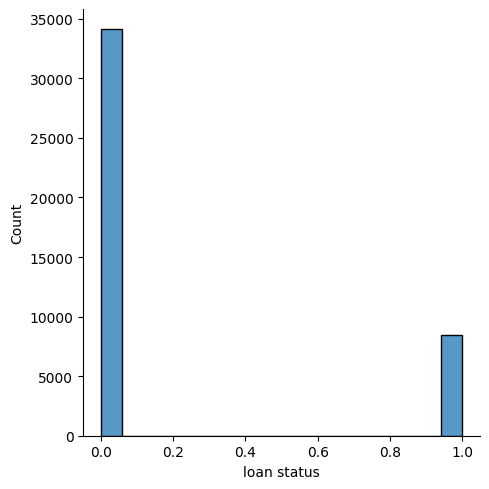

In [ ]:
#Distribution of the Target variable ('Loan Status')
sns.displot(loan_lc['loan status'])
plt.show()

In [ ]:
#Correlation of numerical variables, to see if there are two independent variables that are highly correlated
loan_lc[['revol_bal', 'dti', 'funded_amnt_inv', 'revol_util', 'annual_inc',
       'funded_amnt', 'loan_amnt', ' 36 months', ' 60 months', 'B', 'C', 'D',
       'E', 'F', 'G', 'delinq_2yrs', 'loan status']].corr()

,revol_bal,dti,funded_amnt_inv,revol_util,annual_inc,funded_amnt,loan_amnt,36 months,60 months,B,C,D,E,F,G,delinq_2yrs,loan status
revol_bal,1.000000,0.164610,0.041139,0.194222,0.040438,0.250313,0.254293,-0.029493,0.029496,-0.004300,0.004703,0.019027,0.030685,0.035372,0.055928,-0.043061,0.085276
dti,0.164610,1.000000,0.001180,0.187451,-0.001879,0.068512,0.069130,-0.068844,0.068850,0.002351,0.024183,0.031390,0.032697,0.026315,0.031360,-0.029954,0.030403
funded_amnt_inv,0.041139,0.001180,1.000000,-0.013475,0.001750,0.053409,0.060456,0.017887,-0.017889,-0.041717,0.010178,0.022921,0.011968,0.019593,0.011451,0.014209,0.041095
revol_util,0.194222,0.187451,-0.013475,1.000000,0.011300,0.060498,0.056906,-0.055151,0.055156,-0.050840,0.099251,0.148678,0.148785,0.106121,0.071399,-0.040068,0.082799
annual_inc,0.040438,-0.001879,0.001750,0.011300,1.000000,0.041575,0.041555,-0.010185,0.010186,-0.012176,0.000060,0.000304,0.008061,0.015732,0.002170,-0.004209,0.001047
funded_amnt,0.250313,0.068512,0.053409,0.060498,0.041575,1.000000,0.981746,-0.335103,0.335133,-0.002561,-0.012032,0.046879,0.137576,0.141989,0.090542,-0.033409,0.000445
loan_amnt,0.254293,0.069130,0.060456,0.056906,0.041555,0.981746,1.000000,-0.355611,0.355643,-0.003622,-0.014920,0.041566,0.143596,0.145271,0.089398,-0.032756,0.002885
36 months,-0.029493,-0.068844,0.017887,-0.055151,-0.010185,-0.335103,-0.355611,1.000000,-0.999816,0.056699,-0.018213,-0.094089,-0.240717,-0.171924,-0.078546,-0.001562,-0.077913
60 months,0.029496,0.068850,-0.017889,0.055156,0.010186,0.335133,0.355643,-0.999816,1.000000,-0.056601,0.018297,0.094163,0.240786,0.171967,0.078570,0.001563,0.077596
B,-0.004300,0.002351,-0.041717,-0.050840,-0.012176,-0.002561,-0.003622,0.056699,-0.056601,1.000000,-0.325981,-0.260171,-0.188758,-0.113861,-0.070755,-0.047293,-0.086462


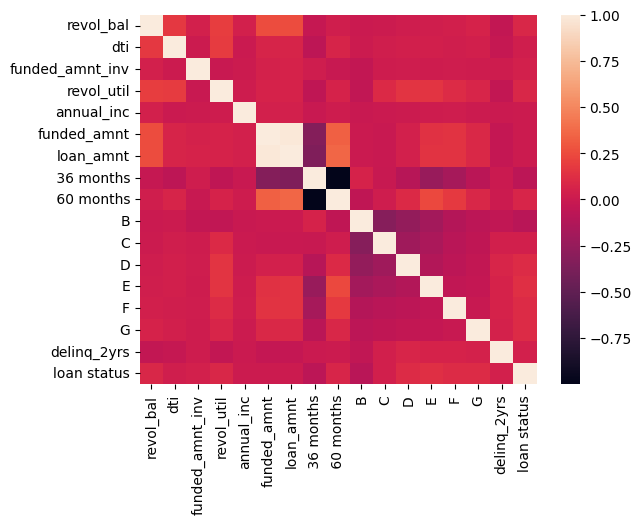

In [ ]:
#Correlation map of variables
sns.heatmap(loan_lc[['revol_bal', 'dti', 'funded_amnt_inv', 'revol_util', 'annual_inc',
       'funded_amnt', 'loan_amnt', ' 36 months', ' 60 months', 'B', 'C', 'D',
       'E', 'F', 'G', 'delinq_2yrs', 'loan status']].corr())
plt.show()

We examine whether there are any missing values.

In [ ]:
loan_lc.isnull().sum()

,0
revol_bal,0
dti,0
funded_amnt_inv,0
revol_util,0
annual_inc,0
funded_amnt,0
loan_amnt,0
36 months,0
60 months,0
B,0


We split the dataset

In [ ]:
# define variables
X = loan_lc.drop('loan status', axis=1)
y = loan_lc['loan status']

# divide data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=123456789
)

In [ ]:
#X_train, X_test, y_train, y_test = train_test_split(loan_lc.drop('loan status',axis=1),
    #                                                loan_lc['loan status'], test_size=0.30,
    #                                                random_state=123456789)

In [ ]:
X_train

,revol_bal,dti,funded_amnt_inv,revol_util,annual_inc,funded_amnt,loan_amnt,36 months,60 months,B,C,D,E,F,G,delinq_2yrs
Unnamed: 0,,,,,,,,,,,,,,,,
7108,442.0,45.0,1.500000e+04,5.5,195000.0,15000.0,15000.0,0,1,1,0,0,0,0,0,0.0
34655,3066.0,1594.0,3.000000e+03,57.8,56400.0,3000.0,3000.0,1,0,1,0,0,0,0,0,0.0
17609,6048.0,334.0,3.000000e+03,51.3,42000.0,3000.0,3000.0,1,0,1,0,0,0,0,0,0.0
22335,5.0,13.0,1.166679e+09,0.0,47952.0,11750.0,15000.0,1,0,0,0,0,0,0,0,0.0
22352,23379.0,1654.0,1.197500e+04,54.8,110000.0,12000.0,12000.0,0,1,1,0,0,0,0,0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17181,45061.0,1453.0,3.180000e+04,82.7,56000.0,31825.0,31825.0,0,1,0,0,0,0,1,0,0.0
4442,4816.0,862.0,1.000000e+04,38.8,43000.0,10000.0,10000.0,1,0,0,1,0,0,0,0,0.0
6105,8169.0,1045.0,1.500000e+03,24.6,70632.0,1500.0,1500.0,1,0,1,0,0,0,0,0,0.0


In [ ]:
X_test

,revol_bal,dti,funded_amnt_inv,revol_util,annual_inc,funded_amnt,loan_amnt,36 months,60 months,B,C,D,E,F,G,delinq_2yrs
Unnamed: 0,,,,,,,,,,,,,,,,
33875,3706.0,1309.0,9825.0,11.20,53000.0,10000.0,10000.0,1,0,0,0,0,0,0,0,0.0
3773,10078.0,1397.0,1800.0,14.10,62000.0,1800.0,1800.0,1,0,1,0,0,0,0,0,0.0
23761,6151.0,1955.0,24875.0,22.80,61000.0,25000.0,25000.0,1,0,0,0,1,0,0,0,0.0
13323,35341.0,1999.0,9775.0,12.70,80000.0,9775.0,10000.0,1,0,0,0,0,0,0,0,0.0
3867,6290.0,2738.0,10575.0,46.30,33000.0,10625.0,10625.0,1,0,0,0,0,0,0,0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12599,7793.0,1354.0,1000.0,66.60,28000.0,1000.0,1000.0,1,0,0,1,0,0,0,0,0.0
24,5963.0,24.0,6000.0,29.70,76000.0,6000.0,6000.0,1,0,1,0,0,0,0,0,0.0
7670,3870.0,316.0,4000.0,0.43,38400.0,4000.0,4000.0,1,0,1,0,0,0,0,0,0.0


In [ ]:
y_train

,loan status
Unnamed: 0,
7108,0
34655,0
17609,1
22335,0
22352,0
...,...
17181,1
4442,0
6105,0


In [ ]:
y_test

,loan status
Unnamed: 0,
33875,0
3773,0
23761,0
13323,0
3867,0
...,...
12599,0
24,1
7670,0


Initial EDA is done. Will now create 3 seperate ML models to predict Future loans status and compare and choice the best model.

##Tuned Logistics Regression Model

In [ ]:
# Define the parameter grid to test
param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'solver': ['lbfgs']
}

# Configure GridSearchCV
log_reg_tuning = LogisticRegression(max_iter=1000, random_state=123)
grid_search = GridSearchCV(estimator=log_reg_tuning,
                           param_grid=param_grid,
                           cv=5,
                           verbose=0)

# Execute the search
grid_search.fit(X_train, y_train)

# Show the best parameters found
print("\nBest C found:", grid_search.best_params_['C'])


Best C found: 0.001


In [ ]:
# The best model is already trained in .best_estimator_
best_log_reg = grid_search.best_estimator_

# Predict the test set with the tuned model
y_pred_tuned = best_log_reg.predict(X_test)

# Visualize prediction results
df_results = X_test.copy()
df_results['target'] = y_test
df_results['prediction'] = y_pred_tuned
df_results.head()

,revol_bal,dti,funded_amnt_inv,revol_util,annual_inc,funded_amnt,loan_amnt,36 months,60 months,B,C,D,E,F,G,delinq_2yrs,target,prediction
Unnamed: 0,,,,,,,,,,,,,,,,,,
33875,3706.0,1309.0,9825.0,11.2,53000.0,10000.0,10000.0,1,0,0,0,0,0,0,0,0.0,0,0
3773,10078.0,1397.0,1800.0,14.1,62000.0,1800.0,1800.0,1,0,1,0,0,0,0,0,0.0,0,0
23761,6151.0,1955.0,24875.0,22.8,61000.0,25000.0,25000.0,1,0,0,0,1,0,0,0,0.0,0,0
13323,35341.0,1999.0,9775.0,12.7,80000.0,9775.0,10000.0,1,0,0,0,0,0,0,0,0.0,0,0
3867,6290.0,2738.0,10575.0,46.3,33000.0,10625.0,10625.0,1,0,0,0,0,0,0,0,0.0,0,0


In [ ]:
print("--- Confusion Matrix of the Tuned Model ---")
print(confusion_matrix(y_test, y_pred_tuned))

print("\n--- Classification Report of the Tuned Model ---")
print(classification_report(y_test, y_pred_tuned))

--- Confusion Matrix of the Tuned Model ---
[[10157    28]
 [ 2546    31]]

--- Classification Report of the Tuned Model ---
              precision    recall  f1-score   support

           0       0.80      1.00      0.89     10185
           1       0.53      0.01      0.02      2577

    accuracy                           0.80     12762
   macro avg       0.66      0.50      0.46     12762
weighted avg       0.74      0.80      0.71     12762



In [ ]:
# Coefficients of the tuned model (best_log_reg)
tuned_coefs = best_log_reg.coef_[0]
tuned_odds_ratio = np.exp(tuned_coefs)

df_interpret_tuned = pd.DataFrame({
    'Variable': X.columns,
    'Coefficient': tuned_coefs,
    'Multiplier (e^Coef)': tuned_odds_ratio
})
print(df_interpret_tuned.sort_values(by='Coefficient', ascending=False))

           Variable   Coefficient  Multiplier (e^Coef)
6         loan_amnt  1.116566e-05             1.000011
0         revol_bal  8.952102e-06             1.000009
12                E  7.700696e-08             1.000000
8         60 months  6.806632e-08             1.000000
13                F  5.278093e-08             1.000000
11                D  4.233403e-08             1.000000
14                G  2.753969e-08             1.000000
2   funded_amnt_inv  7.715783e-12             1.000000
15      delinq_2yrs -3.009217e-08             1.000000
4        annual_inc -6.754477e-08             1.000000
10                C -6.976553e-08             1.000000
9                 B -2.444165e-07             1.000000
7         36 months -5.533858e-07             0.999999
3        revol_util -1.422358e-05             0.999986
5       funded_amnt -8.183776e-05             0.999918
1               dti -4.878409e-04             0.999512


**Interpretation of the coefficients – loan_lc model**

The logistic regression model predicts the probability that a loan is fully paid (Loan Status = 1).

Each variable has a coefficient. This coefficient shows two things:

1. The sign (+ or −): direction

Positive sign (+) → increases the probability of loan fully paid

Negative sign (−) → decreases the probability of loan fully paid

Example:

annual income(annual_inc) has a negative sign → having a low annual income decreases the probability of the loan fully paid.

2. The size of the coefficient: importance

Big number → very important variable

Small number → less important variable

The sign shows direction, and the size shows importance.

**summary**

loans to customers with higher revolving balance and duration of 60 months had higher probability of been fully paid

Loans to customers with lower revoling balance and 36 months durability had lower probability of been fully paid.

Revolving and loan period are the most important variables.

##Tuned Boosting

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier

In [ ]:
# Define the parameter grid to test
param_grid_gb = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [1, 2, 3]
}

# Configure GridSearchCV
gb_for_tuning = GradientBoostingClassifier(random_state=123)
grid_search_gb = GridSearchCV(estimator=gb_for_tuning,
                              param_grid=param_grid_gb,
                              cv=5,
                              scoring='accuracy',
                              verbose=0)

# Execute the search
grid_search_gb.fit(X_train, y_train)

# Show the best parameters found
print("\nBest parameters found:")
print(grid_search_gb.best_params_)


Best parameters found:
{'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200}


In [ ]:
# The best model is already trained in .best_estimator_
best_gb = grid_search_gb.best_estimator_

# Predict the test set with the tuned model
y_pred_tuned = best_gb.predict(X_test)

# Visualize prediction results
df_results = X_test.copy()
df_results['actual_class'] = y_test
df_results['prediction'] = y_pred_tuned
df_results.head()

,revol_bal,dti,funded_amnt_inv,revol_util,annual_inc,funded_amnt,loan_amnt,36 months,60 months,B,C,D,E,F,G,delinq_2yrs,actual_class,prediction
Unnamed: 0,,,,,,,,,,,,,,,,,,
33875,3706.0,1309.0,9825.0,11.2,53000.0,10000.0,10000.0,1,0,0,0,0,0,0,0,0.0,0,0
3773,10078.0,1397.0,1800.0,14.1,62000.0,1800.0,1800.0,1,0,1,0,0,0,0,0,0.0,0,0
23761,6151.0,1955.0,24875.0,22.8,61000.0,25000.0,25000.0,1,0,0,0,1,0,0,0,0.0,0,0
13323,35341.0,1999.0,9775.0,12.7,80000.0,9775.0,10000.0,1,0,0,0,0,0,0,0,0.0,0,0
3867,6290.0,2738.0,10575.0,46.3,33000.0,10625.0,10625.0,1,0,0,0,0,0,0,0,0.0,0,0


In [ ]:
print("--- Confusion Matrix of the Tuned GB ---")
print(confusion_matrix(y_test, y_pred_tuned))

print("\n--- Classification Report of the Tuned GB ---")
print(classification_report(y_test, y_pred_tuned))

--- Confusion Matrix of the Tuned GB ---
[[10068   117]
 [ 2197   380]]

--- Classification Report of the Tuned GB ---
              precision    recall  f1-score   support

           0       0.82      0.99      0.90     10185
           1       0.76      0.15      0.25      2577

    accuracy                           0.82     12762
   macro avg       0.79      0.57      0.57     12762
weighted avg       0.81      0.82      0.77     12762



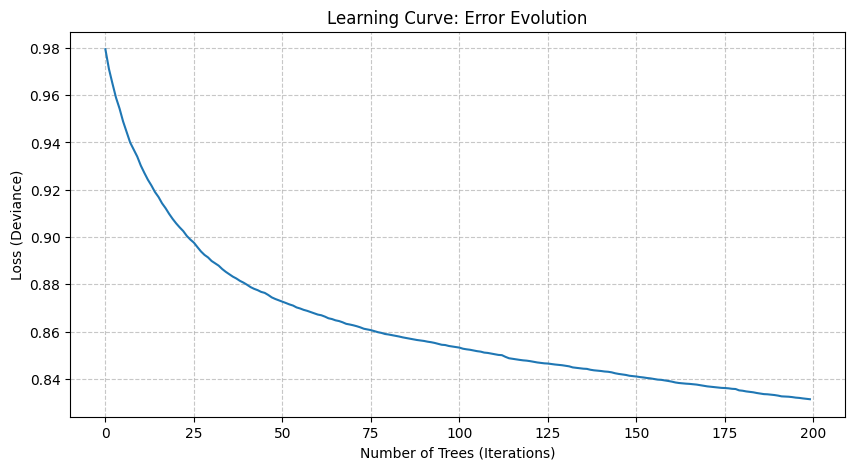

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(best_gb.train_score_)
plt.title("Learning Curve: Error Evolution")
plt.xlabel("Number of Trees (Iterations)")
plt.ylabel("Loss (Deviance)")
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

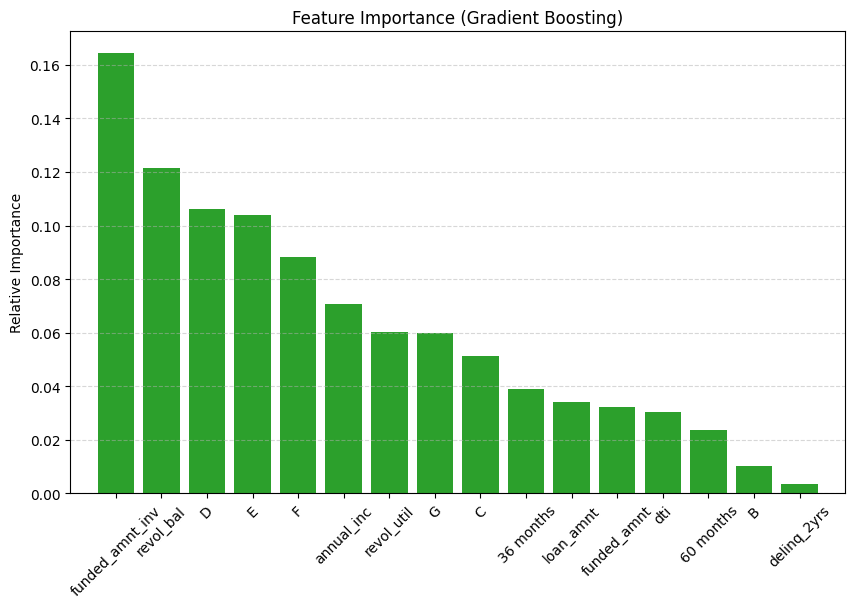

In [ ]:
# Extract feature importances
importances = best_gb.feature_importances_
indices = np.argsort(importances)[::-1]

# Plot
plt.figure(figsize=(10, 6))
plt.title("Feature Importance (Gradient Boosting)")
plt.bar(range(X.shape[1]), importances[indices], align="center", color='#2ca02c') # Green
plt.xticks(range(X.shape[1]), X.columns[indices], rotation=45)
plt.xlim([-1, X.shape[1]])
plt.ylabel("Relative Importance")
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

##Summary:   
According to the model, the Funded amount from ivestors and revolving balance were the main features that contributed to the loan been fully paid or not. After these the class of Loan (D,E or F) were important features in determining weather the Loan will be fully paid or not.

## Naive Bayes

In [ ]:
from sklearn.naive_bayes import GaussianNB

In [ ]:
model_nb = GaussianNB()
model_nb.fit(X_train, y_train)
print("Naive Bayes Model trained.")

Naive Bayes Model trained.


In [ ]:
# Prediction
y_pred = model_nb.predict(X_test)

# Visualize prediction results
df_results = X_test.copy()
df_results['target'] = y_test
df_results['prediction'] = y_pred
df_results.head()

,revol_bal,dti,funded_amnt_inv,revol_util,annual_inc,funded_amnt,loan_amnt,36 months,60 months,B,C,D,E,F,G,delinq_2yrs,target,prediction
Unnamed: 0,,,,,,,,,,,,,,,,,,
33875,3706.0,1309.0,9825.0,11.2,53000.0,10000.0,10000.0,1,0,0,0,0,0,0,0,0.0,0,0
3773,10078.0,1397.0,1800.0,14.1,62000.0,1800.0,1800.0,1,0,1,0,0,0,0,0,0.0,0,0
23761,6151.0,1955.0,24875.0,22.8,61000.0,25000.0,25000.0,1,0,0,0,1,0,0,0,0.0,0,0
13323,35341.0,1999.0,9775.0,12.7,80000.0,9775.0,10000.0,1,0,0,0,0,0,0,0,0.0,0,0
3867,6290.0,2738.0,10575.0,46.3,33000.0,10625.0,10625.0,1,0,0,0,0,0,0,0,0.0,0,0


In [ ]:
# Confusion Matrix
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# Classification Report
print("\nReport:")
print(classification_report(y_test, y_pred))

Confusion Matrix:
[[9978  207]
 [2501   76]]

Report:
              precision    recall  f1-score   support

           0       0.80      0.98      0.88     10185
           1       0.27      0.03      0.05      2577

    accuracy                           0.79     12762
   macro avg       0.53      0.50      0.47     12762
weighted avg       0.69      0.79      0.71     12762



In [ ]:
# Extract learned means
class_names = ['default', 'fully paid']

df_means = pd.DataFrame(model_nb.theta_,
                         columns=X_train.columns,
                         index=class_names)

print("Learned Means (Centroids of the distributions):")
print(df_means.round(2))

Learned Means (Centroids of the distributions):
            revol_bal      dti  funded_amnt_inv  revol_util  annual_inc  \
default       13298.4  1184.34     5.227263e+08       43.01   119873.88   
fully paid    18343.4  1238.65     6.848665e+08       49.22   124185.68   

            funded_amnt  loan_amnt   36 months   60 months     B     C     D  \
default        10851.56   11113.34        0.76        0.24  0.31  0.20  0.12   
fully paid     10815.81   11100.63        0.68        0.32  0.21  0.24  0.22   

               E     F     G  delinq_2yrs  
default     0.06  0.02  0.01         0.14  
fully paid  0.15  0.07  0.03         0.19  


**summary**: This table shows the average values for loans that were fully paid or were deflauts. We can see that loans given customers with slightly higher annual income, revolving balance,dti and revolving Util were more often fully paid whereas 36 months loans with slightly lower income and revolving balance and revolving Util were the most default

##**Comparison of Models**

The best Model based on Accuracy is the Boosting Model with an accuracy rate of 82% and the poorest is the Naive Bayes with 79% accurracy. The Logistics regression model was only able to correctly predict 80% of the loan status of the test data with and is probably overfitted with a 100% Recall.

What this means is that the Boosting model was that able to predict 82% of the test loan data correctly.